<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_vs_mlp_sp2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

Задача: сгенерировать данные затухающего гармонического осциллятора и восстановить закон движения.

# **Установка библиотек**

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-wn5l6aof
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-wn5l6aof
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=ffe914195ae5c8748c75d067ee4882247f35b56b8285e6fbb2e89e758b74b5b1
  Stored in directory: /tmp/pip-ephem-wheel-cache-jfv6pcrk/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


# **Генерация данных**

In [ ]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v  # правая часть уравнения
    return [v, a]

all_data = []

for k in [2.0, 4.0, 6.0]:
  for c in [0.1, 0.3, 0.5]:
    for m in [0.5, 1.0, 2.0]:

      for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
        for v0 in [0.0, 0.5, 1.0]:

          sol = solve_ivp(rhs, (0, 20), y0=[x0, v0], t_eval=np.linspace(0, 10, 100))
          x, v = sol.y
          a_clean = -(k/m)*x - (c/m)*v # истинное ускорение

          for i in range(len(x)):
            all_data.append([x[i], v[i], k, c, 1/m, a_clean[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # (x, v, k, c, 1/m)
y = all_data[:, 5]    # a

# Разбиение на train/test (исходное)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование только x и v (обучаем scaler на трейне, применяем ко всем)
from sklearn.preprocessing import StandardScaler
scaler_dyn = StandardScaler()
scaler_dyn.fit(X_train[:, :2])
X_train[:, :2] = scaler_dyn.transform(X_train[:, :2])
X_test[:, :2]  = scaler_dyn.transform(X_test[:, :2])

# Подвыборки
n_train = 6000
indices_train = np.random.choice(len(X_train), size=n_train, replace=False)
X_train_sub = X_train[indices_train]
y_train_sub = y_train[indices_train]

n_test = 1500
indices_test = np.random.choice(len(X_test), size=n_test, replace=False)
X_test_sub = X_test[indices_test]
y_test_sub = y_test[indices_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input': X_test_t,
    'test_label': y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")

Всего точек: 40500
train: 6000 примеров, test: 1500 примеров


# **Обучение KAN**

KAN [5, 4, 1], grid=5, k=1

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 7.77e-02 | test_loss: 7.95e-02 | reg: 1.96e+01 | : 100%|█| 1000/1000 [01:03<00:00, 15.


saving model version 0.1


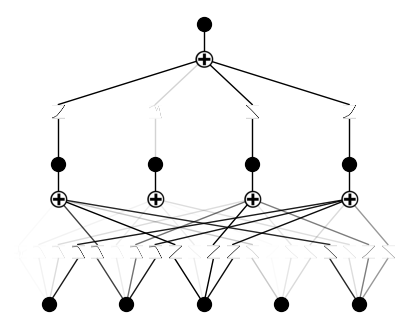

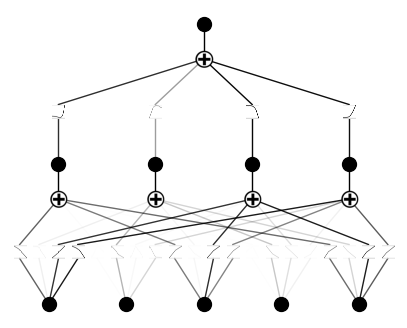

In [ ]:
model_kan = KAN(width=[5, 4, 1], grid=5, k=1, seed=42, device=device)

model_kan(dataset['train_input']);
model_kan.plot()

model_kan.fit(dataset, opt="Adam", steps=1000, lr=0.01)
model_kan.plot()

In [ ]:
model_kan.fit(dataset, opt="LBFGS", steps=500, lr=0.5, lamb=0.0, lamb_entropy=1e-6)
model_kan.plot()

| train_loss: 5.10e-02 | test_loss: 4.89e-02 | reg: 0.00e+00 | :  58%|▌| 288/500 [08:27<07:32,  2.13

saving model version 0.3


| train_loss: 5.68e-02 | test_loss: 6.88e-02 | reg: 2.62e+01 | : 100%|█| 200/200 [01:49<00:00,  1.83


saving model version 0.4


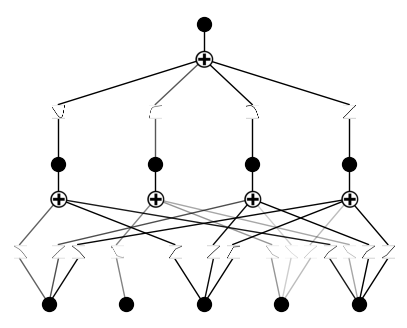

In [ ]:
model_kan = model_kan.prune()
model_kan.fit(dataset, opt="LBFGS", steps=200, lr=0.5, update_grid=False)
model_kan.plot()

In [ ]:
lib = ['x','x^2','x^3','x^4','exp','log','sqrt','tanh','sin','abs']
model_kan.auto_symbolic(lib=lib)
formula = ex_round(model_kan.symbolic_formula()[0][0],4)
print("Символьная формула KAN: ")

KAN

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.36e-01 | test_loss: 1.45e-01 | reg: 2.04e+01 | : 100%|█| 1000/1000 [01:11<00:00, 14.


saving model version 0.1


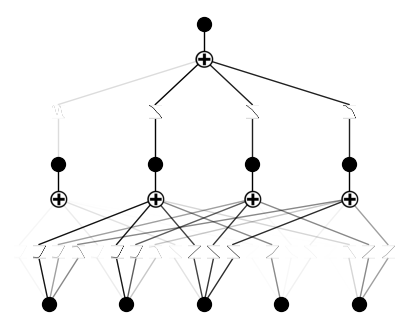

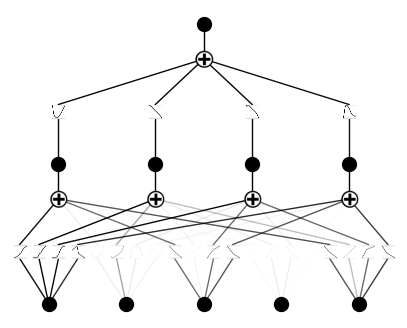

In [ ]:
model_kan = KAN(width=[5, 4, 1], grid=8, k=3, seed=42, device=device)

model_kan(dataset['train_input']);
model_kan.plot()

model_kan.fit(dataset, opt="Adam", steps=1000, lr=0.01)
model_kan.plot()

| train_loss: 3.00e-02 | test_loss: 3.06e-02 | reg: 2.10e+01 | : 100%|█| 500/500 [10:26<00:00,  1.25


saving model version 0.2


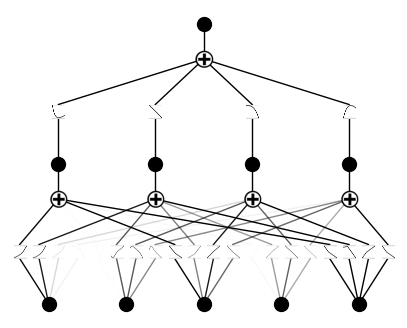

In [ ]:
model_kan.fit(dataset, opt="LBFGS", steps=500, lr=0.5, lamb=0.0, lamb_entropy=1e-6)
model_kan.plot()

saving model version 0.3


| train_loss: 2.49e-02 | test_loss: 2.90e-02 | reg: 3.17e+01 | : 100%|█| 200/200 [04:19<00:00,  1.30


saving model version 0.4


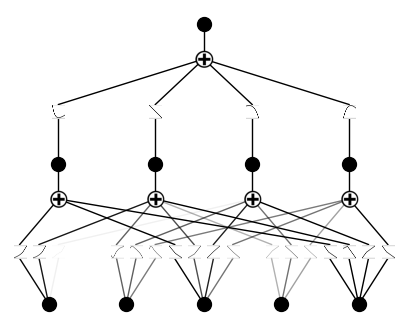

In [ ]:
model_kan = model_kan.prune()
model_kan.fit(dataset, opt="LBFGS", steps=200, lr=0.5, update_grid=False)
model_kan.plot()